In [1]:
import os
import umap
import time
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

/Users/tomastokar/anaconda3/envs/PyMuvae/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [7]:
PATH = './results/MNIST_qualitative/'
SEED = 11

In [8]:
fn = os.path.join(PATH, 'embeddings.npz')
data = np.load(fn, allow_pickle=True)
grouped_data = defaultdict(dict)
for key in data:
    agg_func, model = key.split('/')
    grouped_data[agg_func][model] = data[key].item() 

In [9]:
projections = defaultdict(dict)
umap_model = umap.UMAP(random_state=SEED)
start = time.time()
for agg_func in grouped_data:
    for model in grouped_data[agg_func]:
        try:
            z = grouped_data[agg_func][model]['z']
            z_umap = umap_model.fit_transform(z)
            projections[agg_func][model] = z_umap
        except:
            projections[agg_func][model] = None
        print('{}; {}; Elapsed time: {:1.2f}'.format(agg_func, model, time.time() - start))

/Users/tomastokar/anaconda3/envs/PyMuvae/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


mean; DeepSet; Elapsed time: 1.66
mean; MeanSet; Elapsed time: 3.34
mean; PointNet; Elapsed time: 4.90
mean; HPDS; Elapsed time: 6.51
mean; QUANN; Elapsed time: 8.15
mean; SetTransformer; Elapsed time: 9.81
mean; QUANNTransformer; Elapsed time: 11.48
mode; DeepSet; Elapsed time: 13.15
mode; MeanSet; Elapsed time: 14.73
mode; PointNet; Elapsed time: 16.39
mode; HPDS; Elapsed time: 18.03
mode; QUANN; Elapsed time: 19.73
mode; SetTransformer; Elapsed time: 21.43
mode; QUANNTransformer; Elapsed time: 23.05
variance; DeepSet; Elapsed time: 24.72
variance; MeanSet; Elapsed time: 26.42
variance; PointNet; Elapsed time: 28.05
variance; HPDS; Elapsed time: 29.63
variance; QUANN; Elapsed time: 31.31
variance; SetTransformer; Elapsed time: 32.96
variance; QUANNTransformer; Elapsed time: 34.53
max; DeepSet; Elapsed time: 36.15
max; MeanSet; Elapsed time: 37.79
max; PointNet; Elapsed time: 39.38
max; HPDS; Elapsed time: 40.91
max; QUANN; Elapsed time: 42.49
max; SetTransformer; Elapsed time: 44.08


/var/folders/bf/lyf84ddj5cl3ph3d4sz71xjc0000gn/T/ipykernel_39121/1581898603.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(classes))


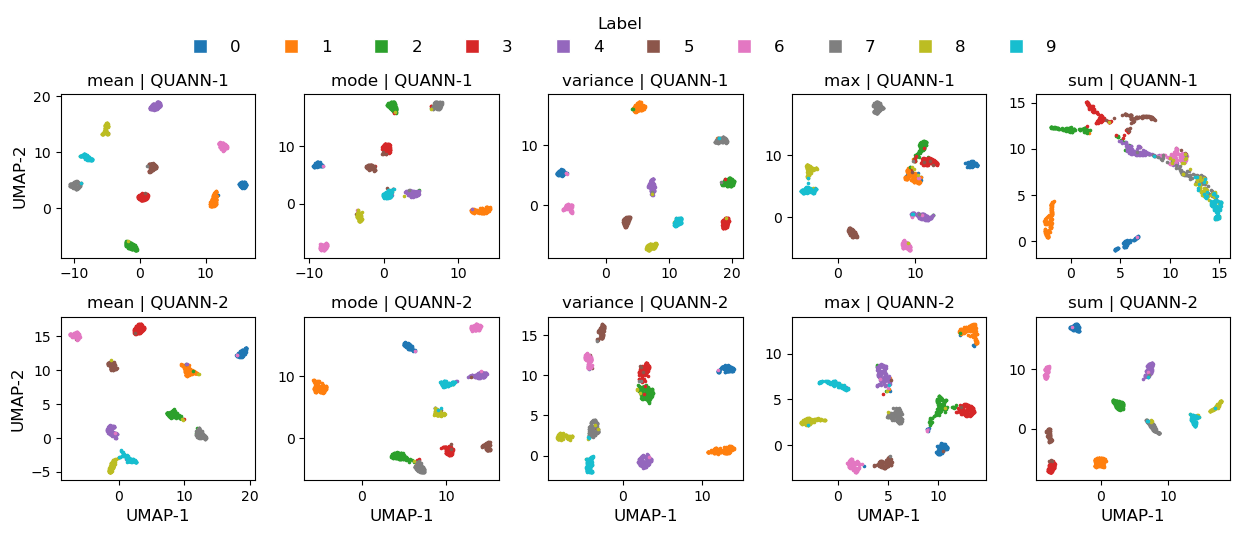

In [19]:
num_plots = sum(len(models) for models in projections.values())
ncols = len(projections)
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 2.5 * nrows))

for col, agg_func in enumerate(projections):
    for row, model in enumerate(['QUANN', 'QUANNTransformer']):
        z_umap = projections[agg_func][model]

        ax = axes[row, col]
        if z_umap is not None:
            y = grouped_data[agg_func][model]['y']
                
            classes = np.unique(y)
            cmap = cm.get_cmap('tab10', len(classes))
            norm = mcolors.Normalize(vmin=0, vmax=len(classes) - 1)
    
            for k, cls in enumerate(classes):
                cls_mask = (y == cls)
                ax.scatter(z_umap[cls_mask, 0], z_umap[cls_mask, 1], label=str(cls), s=10, color=cmap(k), marker = '.')

        if model == 'QUANN':
            model = 'QUANN-1'
        elif model == 'QUANNTransformer':
            model = 'QUANN-2'
        elif model == 'MeanSet':
            model = 'NormDeepSet'
        
        ax.set_title(f"{agg_func} | {model}")
        
        # Show x-label only in last row
        if row == nrows - 1:
            ax.set_xlabel("UMAP-1", fontsize = 12)
        
        # Show y-label only in first column
        if col == 0:
            ax.set_ylabel("UMAP-2", fontsize = 12)    
                
# Get colors
colors = [cmap(k) for k in range(len(classes))]

# Create shared legend
legend_elements = [
    plt.Line2D(
        [0], [0], 
        marker='s', 
        color='w',
        label=str(cls),
        markerfacecolor=colors[k], 
        markersize=10
    ) for k, cls in enumerate(classes)
]

fig.legend(
    handles=legend_elements, 
    title="Label", 
    loc='upper center',
    ncol=len(classes), 
    fontsize=12,
    title_fontsize = 12,
    frameon=False, 
    bbox_to_anchor=(0.5, 1.075)
)

fig.tight_layout(rect=[0, 0, 1, 0.96])  # leave space at bottom for legend
plt.savefig('./results/MNIST_QUANN_UMAPs.png', dpi = 500)
plt.show()

/var/folders/bf/lyf84ddj5cl3ph3d4sz71xjc0000gn/T/ipykernel_39121/157803660.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(classes))


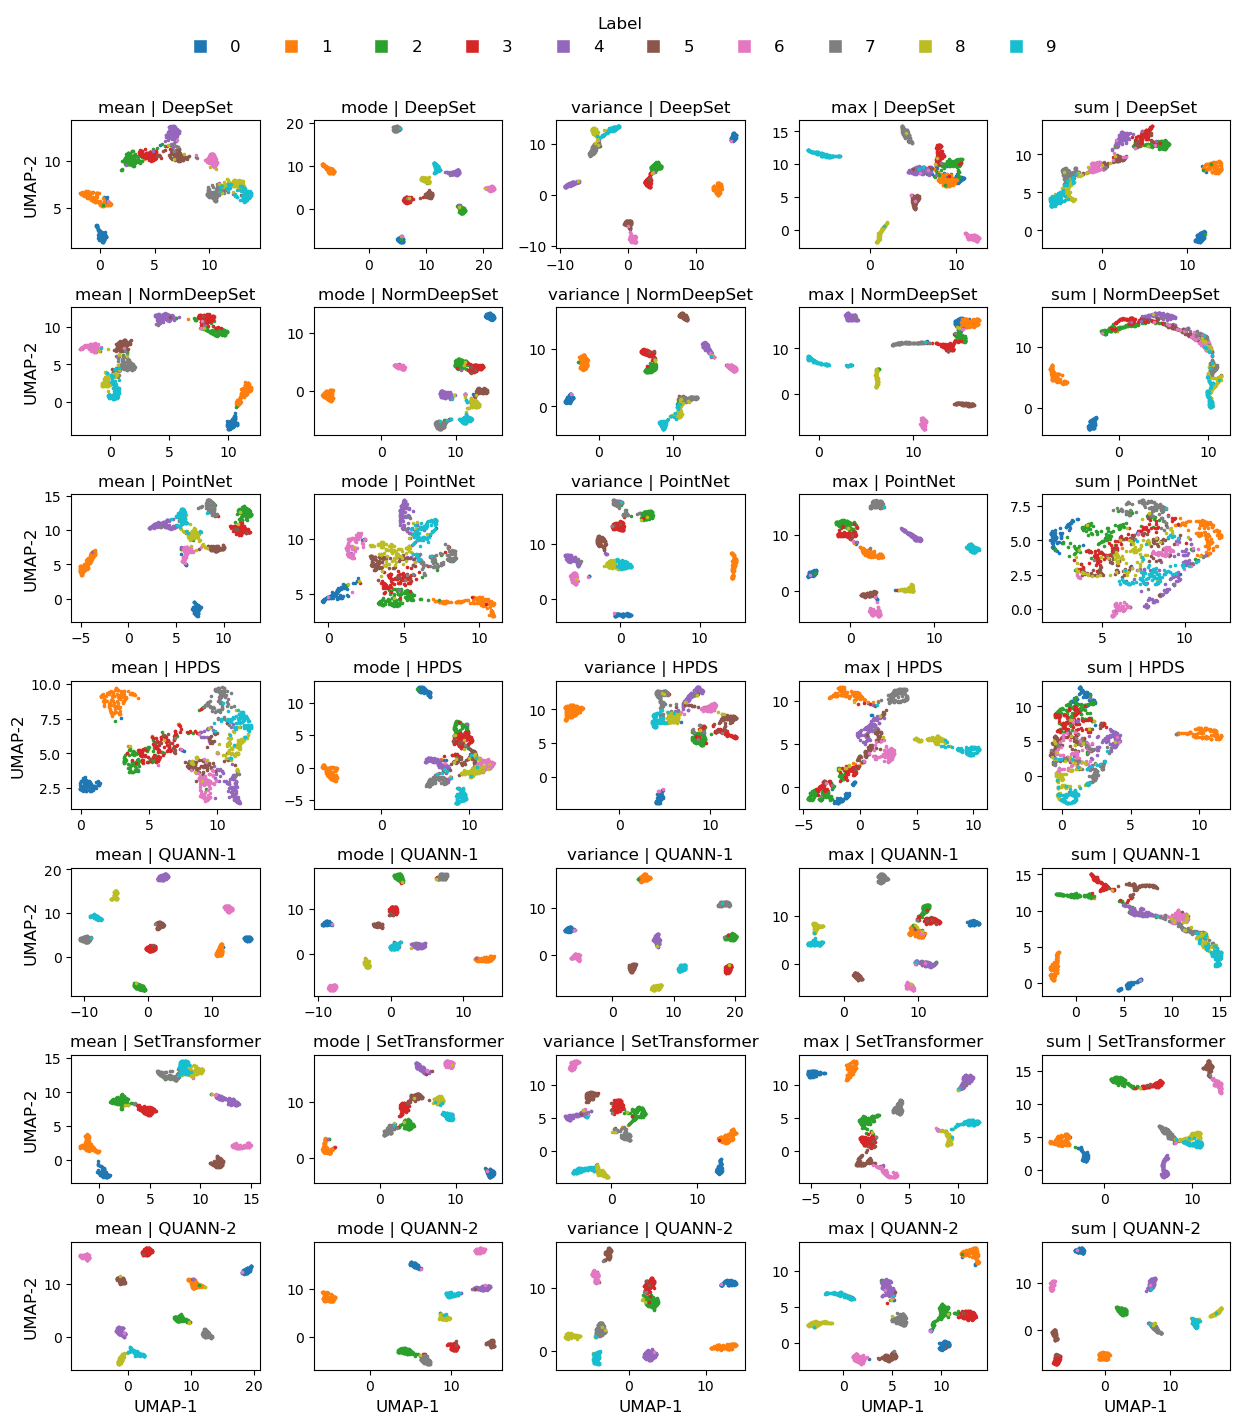

In [15]:
num_plots = sum(len(models) for models in projections.values())
ncols = len(projections)
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 2 * nrows))

for col, agg_func in enumerate(projections):
    for row, model in enumerate(projections[agg_func]):
        z_umap = projections[agg_func][model]

        ax = axes[row, col]
        if z_umap is not None:
            y = grouped_data[agg_func][model]['y']
                
            classes = np.unique(y)
            cmap = cm.get_cmap('tab10', len(classes))
            norm = mcolors.Normalize(vmin=0, vmax=len(classes) - 1)
    
            for k, cls in enumerate(classes):
                cls_mask = (y == cls)
                ax.scatter(z_umap[cls_mask, 0], z_umap[cls_mask, 1], label=str(cls), s=10, color=cmap(k), marker = '.')

        if model == 'QUANN':
            model = 'QUANN-1'
        elif model == 'QUANNTransformer':
            model = 'QUANN-2'
        elif model == 'MeanSet':
            model = 'NormDeepSet'
        
        ax.set_title(f"{agg_func} | {model}")
        
        # Show x-label only in last row
        if row == nrows - 1:
            ax.set_xlabel("UMAP-1", fontsize = 12)
        
        # Show y-label only in first column
        if col == 0:
            ax.set_ylabel("UMAP-2", fontsize = 12)    
                
# Get colors
colors = [cmap(k) for k in range(len(classes))]

# Create shared legend
legend_elements = [
    plt.Line2D(
        [0], [0], 
        marker='s', 
        color='w',
        label=str(cls),
        markerfacecolor=colors[k], 
        markersize=10
    ) for k, cls in enumerate(classes)
]

fig.legend(
    handles=legend_elements, 
    title="Label", 
    loc='upper center',
    ncol=len(classes), 
    fontsize=12,
    title_fontsize = 12,
    frameon=False, 
    bbox_to_anchor=(0.5, 1.02)
)

fig.tight_layout(rect=[0, 0, 1, 0.96])  # leave space at bottom for legend
plt.savefig('./results/MNIST_UMAPs.png', dpi = 500)
plt.show()